<a href="https://colab.research.google.com/github/arpit241001001150-gif/machine_learning/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 1: Logistic Regression – Student Placement Prediction

### Objective
To implement Logistic Regression for predicting whether a student will be placed based on academic and skill-related features.

### Problem Statement
A college wants to predict the placement status of students using the following attributes:
*   **CGPA**
*   **IQ Score**
*   **Aptitude Score**
*   **Technical Skill Score**
*   **Communication Skill Score**

The target variable is:
*   **1** → Placed
*   **0** → Not Placed

You are required to build a Logistic Regression model and evaluate its performance.

### Task 1: Create or use a dataset containing at least 100 student records.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

# Number of student records
num_records = 100

# Generate synthetic data
cgpa = np.random.uniform(5.0, 10.0, num_records).round(2)
iq_score = np.random.randint(80, 150, num_records)
aptitude_score = np.random.randint(40, 100, num_records)
technical_skill_score = np.random.randint(30, 95, num_records)
communication_skill_score = np.random.randint(20, 90, num_records)

# Generate 'Placed' status based on a weighted sum of scores with some randomness
# Higher scores generally lead to 'Placed' (1)
placed_probability = (cgpa * 0.2 + iq_score * 0.15 + aptitude_score * 0.2 +
                      technical_skill_score * 0.25 + communication_skill_score * 0.2) / 100
placed = (np.random.rand(num_records) < placed_probability).astype(int)

# Create a DataFrame
data = {
    'CGPA': cgpa,
    'IQ Score': iq_score,
    'Aptitude Score': aptitude_score,
    'Technical Skill Score': technical_skill_score,
    'Communication Skill Score': communication_skill_score,
    'Placed': placed
}
df = pd.DataFrame(data)

# Save the dataset to a CSV file (optional, but good practice)
df.to_csv('student_placement_data.csv', index=False)

print("Synthetic dataset created and saved to 'student_placement_data.csv'")

# Load the dataset and display its information
print("\nDataset Information:")
display(df.info())

print("\nFirst 5 rows of the dataset:")
display(df.head())

Synthetic dataset created and saved to 'student_placement_data.csv'

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CGPA                       100 non-null    float64
 1   IQ Score                   100 non-null    int64  
 2   Aptitude Score             100 non-null    int64  
 3   Technical Skill Score      100 non-null    int64  
 4   Communication Skill Score  100 non-null    int64  
 5   Placed                     100 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 4.8 KB


None


First 5 rows of the dataset:


,CGPA,IQ Score,Aptitude Score,Technical Skill Score,Communication Skill Score,Placed
0,6.87,142,98,89,88,1
1,9.75,131,94,92,53,1
2,8.66,83,48,61,71,1
3,7.99,102,80,62,29,0
4,5.78,94,74,47,38,1


### Task 2: Perform basic data preprocessing.

In [ ]:
# Basic data preprocessing - check for null values and data types
# (Already checked by df.info() and confirmed no nulls and correct dtypes for this synthetic data)
print("\nChecking for missing values:")
display(df.isnull().sum())


Checking for missing values:


,0
CGPA,0
IQ Score,0
Aptitude Score,0
Technical Skill Score,0
Communication Skill Score,0
Placed,0


### Task 3: Separate the dataset into independent variables (X) and dependent variable (y).
### Task 4: Split the dataset into 80% training and 20% testing data.

In [ ]:
# Separate independent variables (X) and dependent variable (y)
X = df.drop('Placed', axis=1)
y = df['Placed']

print("\nShape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

# Split the dataset into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining and testing dataset sizes:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nValue counts for y_train (to check stratification):")
display(y_train.value_counts())
print("\nValue counts for y_test (to check stratification):")
display(y_test.value_counts())


Shape of X (features): (100, 5)
Shape of y (target): (100,)

Training and testing dataset sizes:
X_train shape: (80, 5)
X_test shape: (20, 5)
y_train shape: (80,)
y_test shape: (20,)

Value counts for y_train (to check stratification):


,count
Placed,
1,42
0,38



Value counts for y_test (to check stratification):


,count
Placed,
1,11
0,9


### Task 5: Train a Logistic Regression model.
### Task 6: Predict the placement status of the test students.
### Task 7: Calculate Accuracy, Precision, Recall, F1-Score.
### Task 8: Generate and display the Confusion Matrix.

In [ ]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for smaller datasets
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

# Predict the placement status on the test data
y_pred = model.predict(X_test)

print("Predictions made on the test set.")

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Generate and display the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (DataFrame):")
display(pd.DataFrame(conf_matrix,
                     index=['Actual Not Placed', 'Actual Placed'],
                     columns=['Predicted Not Placed', 'Predicted Placed']))

# Display classification report for a more detailed view
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression model trained successfully.
Predictions made on the test set.

Accuracy: 0.3500
Precision: 0.4000
Recall: 0.3636
F1-Score: 0.3810

Confusion Matrix (DataFrame):


,Predicted Not Placed,Predicted Placed
Actual Not Placed,3,6
Actual Placed,7,4



Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.33      0.32         9
           1       0.40      0.36      0.38        11

    accuracy                           0.35        20
   macro avg       0.35      0.35      0.35        20
weighted avg       0.35      0.35      0.35        20



### Visualize the Confusion Matrix

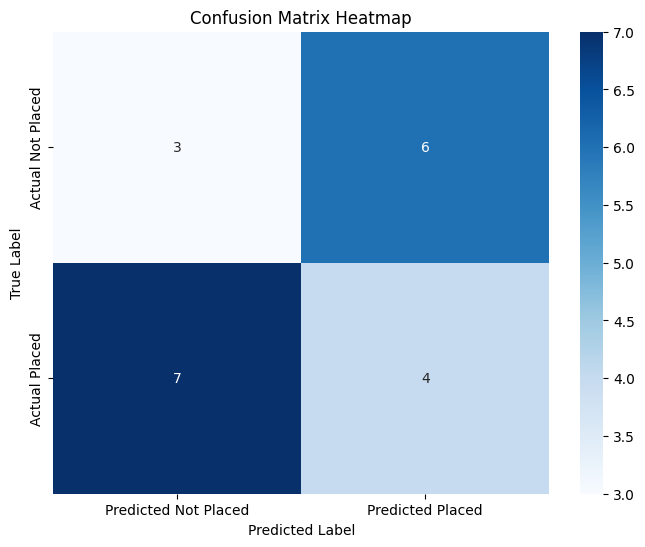

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Not Placed', 'Predicted Placed'],
            yticklabels=['Actual Not Placed', 'Actual Placed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Task 9: Plot the ROC Curve and calculate the AUC score.


ROC-AUC Score: 0.2727


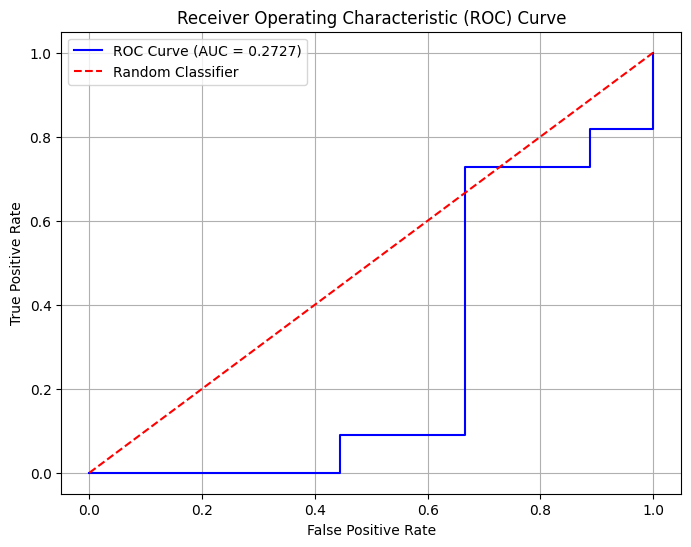

In [ ]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"\nROC-AUC Score: {auc_score:.4f}")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Task 10: Test the model with at least 5 new student records and predict their placement status.

In [ ]:
# Generate 5 new synthetic student records
np.random.seed(99) # New seed for new data for this task
num_new_records = 5

new_cgpa = np.random.uniform(5.0, 10.0, num_new_records).round(2)
new_iq_score = np.random.randint(80, 150, num_new_records)
new_aptitude_score = np.random.randint(40, 100, num_new_records)
new_technical_skill_score = np.random.randint(30, 95, num_new_records)
new_communication_skill_score = np.random.randint(20, 90, num_new_records)

new_data = {
    'CGPA': new_cgpa,
    'IQ Score': new_iq_score,
    'Aptitude Score': new_aptitude_score,
    'Technical Skill Score': new_technical_skill_score,
    'Communication Skill Score': new_communication_skill_score
}

new_students_df = pd.DataFrame(new_data)

print("\nNew student records for prediction:")
display(new_students_df)

# Predict placement status for the new students
new_predictions = model.predict(new_students_df)

# Add predictions to the DataFrame
new_students_df['Predicted Placed'] = new_predictions
new_students_df['Predicted Placed Status'] = new_students_df['Predicted Placed'].map({1: 'Placed', 0: 'Not Placed'})

print("\nPredicted placement status for new students:")
display(new_students_df)


New student records for prediction:


,CGPA,IQ Score,Aptitude Score,Technical Skill Score,Communication Skill Score
0,8.36,81,88,32,79
1,7.44,103,69,94,59
2,9.13,115,99,42,67
3,5.16,135,78,70,47
4,9.04,145,83,50,82



Predicted placement status for new students:


,CGPA,IQ Score,Aptitude Score,Technical Skill Score,Communication Skill Score,Predicted Placed,Predicted Placed Status
0,8.36,81,88,32,79,1,Placed
1,7.44,103,69,94,59,0,Not Placed
2,9.13,115,99,42,67,1,Placed
3,5.16,135,78,70,47,1,Placed
4,9.04,145,83,50,82,1,Placed


---

## Assignment 2: Polynomial Regression – House Price Prediction

### Objective
To implement Polynomial Regression for predicting house prices when the relationship between the input feature and target variable is non-linear.

### Problem Statement
A real-estate company wants to predict the price of a house based on its area. Consider a dataset containing:
Area (sq.ft.) 500 700 900 1100 1300 1500 1700 Price (Lakhs) 20 27 35 46 60 75 93 1900 115 2100 2300 140 168
The relationship between house area and price is assumed to be non-linear.

### Tasks
1.  Create a dataset containing at least 30 house records.
2.  Load the dataset using Pandas.
3.  Perform basic exploratory data analysis.
4.  Visualize the relationship between: House Area and House Price
5.  Divide the data into training and testing sets.
6.  Apply Polynomial Features with degree 2.
7.  Train a Polynomial Regression model.
8.  Repeat the experiment using polynomial degrees: Degree 2, Degree 3, Degree 4
9.  Compare the models using: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R² Score
10. Plot the original data points and the regression curves.
11. Determine which polynomial degree gives the best performance.
12. Predict the price of a house having an area of 2000 sq.ft.

### Task 1: Create a dataset containing at least 30 house records.
### Task 2: Load the dataset using Pandas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

# Create a synthetic dataset with at least 30 house records
area = np.array([500, 700, 900, 1100, 1300, 1500, 1700, 1900, 2100, 2300])
price = np.array([20, 27, 35, 46, 60, 75, 93, 115, 140, 168])

# Extend the dataset to at least 30 records with some randomness
num_additional_records = 20 # To make total 30 records (10 original + 20 additional)
additional_area = np.random.randint(400, 2500, num_additional_records)
# Generate price with a non-linear relationship (quadratic) and some noise
additional_price = (0.00003 * additional_area**2 + 0.02 * additional_area + 5 + np.random.normal(0, 5, num_additional_records)).round(0)

# Combine original and additional data
full_area = np.concatenate((area, additional_area))
full_price = np.concatenate((price, additional_price))

# Create DataFrame
house_data = pd.DataFrame({'Area (sq.ft.)': full_area, 'Price (Lakhs)': full_price})

# Ensure at least 30 records (should be guaranteed by num_additional_records)
if len(house_data) < 30:
    # This block would only run if num_additional_records was too small
    remaining_needed = 30 - len(house_data)
    extra_area = np.random.randint(400, 2500, remaining_needed)
    extra_price = (0.00003 * extra_area**2 + 0.02 * extra_area + 5 + np.random.normal(0, 5, remaining_needed)).round(0)
    extra_df = pd.DataFrame({'Area (sq.ft.)': extra_area, 'Price (Lakhs)': extra_price})
    house_data = pd.concat([house_data, extra_df], ignore_index=True)

# Display the dataset
print("Generated House Price Dataset:")
display(house_data.head())
print(f"Total records: {len(house_data)}")

Generated House Price Dataset:


,Area (sq.ft.),Price (Lakhs)
0,500,20.0
1,700,27.0
2,900,35.0
3,1100,46.0
4,1300,60.0


Total records: 30


### Task 3: Perform basic exploratory data analysis.
### Task 4: Visualize the relationship between House Area and House Price.


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area (sq.ft.)  30 non-null     int64  
 1   Price (Lakhs)  30 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


None


Dataset Description:


,Area (sq.ft.),Price (Lakhs)
count,30.000000,30.000000
mean,1356.233333,86.466667
std,525.986343,49.331205
min,421.000000,13.000000
25%,880.500000,44.000000
50%,1425.000000,79.500000
75%,1698.500000,120.500000
max,2300.000000,178.000000


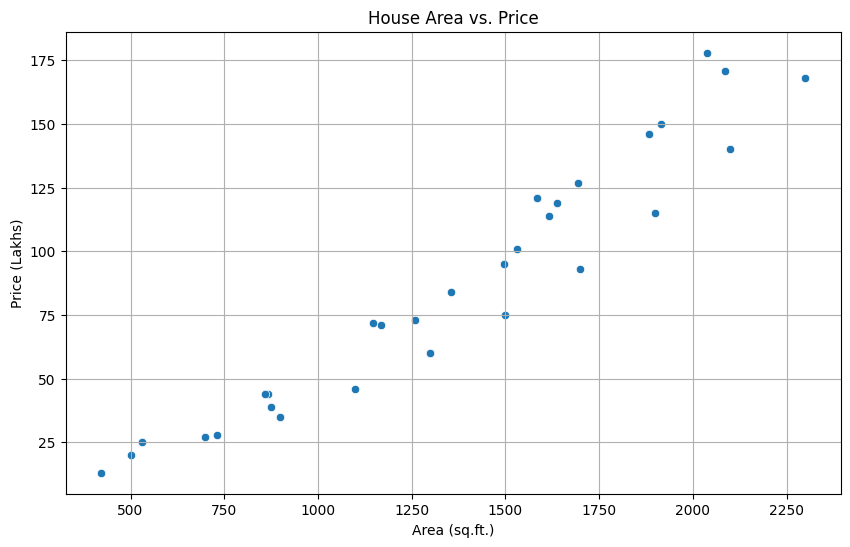

In [ ]:
# Basic EDA - Info and Description
print("\nDataset Information:")
display(house_data.info())

print("\nDataset Description:")
display(house_data.describe())

# Visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Area (sq.ft.)', y='Price (Lakhs)', data=house_data)
plt.title('House Area vs. Price')
plt.xlabel('Area (sq.ft.)')
plt.ylabel('Price (Lakhs)')
plt.grid(True)
plt.show()

### Task 5: Divide the data into training and testing sets.
### Task 6: Apply Polynomial Features (as part of the pipeline).
### Task 7: Train a Polynomial Regression model.
### Task 8: Repeat the experiment using polynomial degrees: Degree 2, Degree 3, Degree 4.

In [ ]:
# Separate features (X) and target (y)
X_poly = house_data[['Area (sq.ft.)']]
y_poly = house_data['Price (Lakhs)']

# Split data into training and testing sets
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train_poly)} records")
print(f"Testing set size: {len(X_test_poly)} records")

# Define polynomial degrees to experiment with
degrees = [2, 3, 4]

# Dictionary to store models and their predictions/metrics
poly_models = {}
poly_predictions = {}
poly_metrics = []

for degree in degrees:
    print(f"\nTraining Polynomial Regression with degree {degree}...")
    # Create a pipeline with PolynomialFeatures and LinearRegression
    model_poly = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())

    # Train the model
    model_poly.fit(X_train_poly, y_train_poly)

    # Store the trained model
    poly_models[degree] = model_poly

    # Make predictions on the test set
    y_pred_poly = model_poly.predict(X_test_poly)
    poly_predictions[degree] = y_pred_poly

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test_poly, y_pred_poly)
    mse = mean_squared_error(y_test_poly, y_pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_poly, y_pred_poly)

    poly_metrics.append({'Degree': degree, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R² Score': r2})

    print(f"Degree {degree} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R² Score: {r2:.2f}")

Training set size: 24 records
Testing set size: 6 records

Training Polynomial Regression with degree 2...
Degree 2 - MAE: 15.40, MSE: 440.50, RMSE: 20.99, R² Score: 0.87

Training Polynomial Regression with degree 3...
Degree 3 - MAE: 16.27, MSE: 535.48, RMSE: 23.14, R² Score: 0.85

Training Polynomial Regression with degree 4...
Degree 4 - MAE: 22.42, MSE: 1075.78, RMSE: 32.80, R² Score: 0.69


### Task 9: Compare the models using MAE, MSE, RMSE, R² Score.

In [ ]:
print("\n--- Polynomial Model Comparison ---")
poly_metrics_df = pd.DataFrame(poly_metrics)
display(poly_metrics_df)

# Determine the best polynomial degree based on R² Score (higher is better)
best_degree_r2_poly = poly_metrics_df.loc[poly_metrics_df['R² Score'].idxmax()]
print(f"\nBest polynomial degree based on R² Score: {int(best_degree_r2_poly['Degree'])} (R² Score: {best_degree_r2_poly['R² Score']:.2f})")

# Alternatively, determine the best degree based on RMSE (lower is better)
best_degree_rmse_poly = poly_metrics_df.loc[poly_metrics_df['RMSE'].idxmin()]
print(f"Best polynomial degree based on RMSE: {int(best_degree_rmse_poly['Degree'])} (RMSE: {best_degree_rmse_poly['RMSE']:.2f})")

# For the purpose of this exercise, we will consider the degree with the highest R² score as 'best'
best_poly_degree = int(best_degree_r2_poly['Degree'])


--- Polynomial Model Comparison ---


,Degree,MAE,MSE,RMSE,R² Score
0,2,15.398688,440.501133,20.988119,0.873343
1,3,16.269707,535.480541,23.140452,0.846034
2,4,22.416976,1075.783581,32.799140,0.690682



Best polynomial degree based on R² Score: 2 (R² Score: 0.87)
Best polynomial degree based on RMSE: 2 (RMSE: 20.99)


### Task 10: Plot the original data points and the regression curves.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


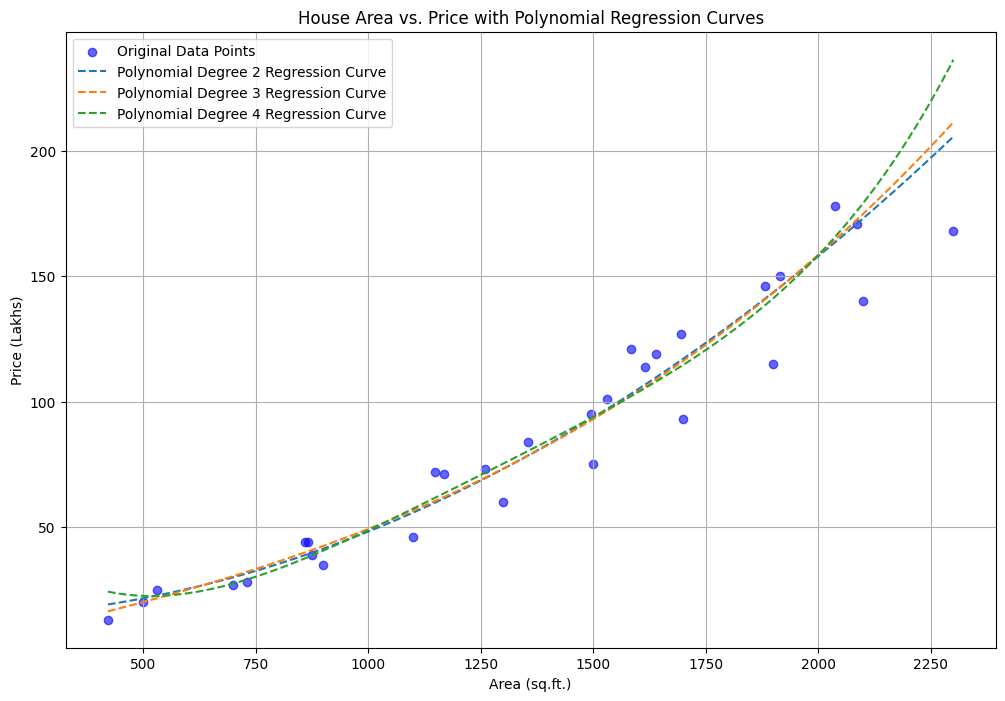

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(X_poly, y_poly, label='Original Data Points', color='blue', alpha=0.6)

X_plot_poly = np.linspace(X_poly.min(), X_poly.max(), 500).reshape(-1, 1)

for degree in degrees:
    y_plot_poly = poly_models[degree].predict(X_plot_poly)
    plt.plot(X_plot_poly, y_plot_poly, label=f'Polynomial Degree {degree} Regression Curve', linestyle='--')

plt.title('House Area vs. Price with Polynomial Regression Curves')
plt.xlabel('Area (sq.ft.)')
plt.ylabel('Price (Lakhs)')
plt.legend()
plt.grid(True)
plt.show()

### Task 11: Determine which polynomial degree gives the best performance.
(Already determined in Task 9 and printed above.)

### Task 12: Predict the price of a house having an area of 2000 sq.ft.

In [ ]:
# Use the best performing model (based on R² Score) for prediction
best_poly_model = poly_models[best_poly_degree]

# Predict for a house with area 2000 sq.ft.
area_to_predict_poly = pd.DataFrame({'Area (sq.ft.)': [2000]})
predicted_price_poly = best_poly_model.predict(area_to_predict_poly)

print(f"\nUsing the best polynomial model (Degree {best_poly_degree}), the predicted price for a house with area 2000 sq.ft. is: {predicted_price_poly[0]:.2f} Lakhs")


Using the best polynomial model (Degree 2), the predicted price for a house with area 2000 sq.ft. is: 158.02 Lakhs
